In [30]:
%matplotlib inline

import os

import pandas as pd

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

import scipy.stats as st
from scipy.optimize import minimize

OSError: 'style.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

#### Shen, Hopkins luminosity function

In [3]:
import sys
sys.path.append("/Users/colinburke/research/quasarlf/pubtools")
os.chdir("/Users/colinburke/research/quasarlf/pubtools")

(array([41.59106461, 41.69106461, 41.79106461, 41.89106461, 41.99106461,
       42.09106461, 42.19106461, 42.29106461, 42.39106461, 42.49106461,
       42.59106461, 42.69106461, 42.79106461, 42.89106461, 42.99106461,
       43.09106461, 43.19106461, 43.29106461, 43.39106461, 43.49106461,
       43.59106461, 43.69106461, 43.79106461, 43.89106461, 43.99106461,
       44.09106461, 44.19106461, 44.29106461, 44.39106461, 44.49106461,
       44.59106461, 44.69106461, 44.79106461, 44.89106461, 44.99106461,
       45.09106461, 45.19106461, 45.29106461, 45.39106461, 45.49106461,
       45.59106461, 45.69106461, 45.79106461, 45.89106461, 45.99106461,
       46.09106461, 46.19106461, 46.29106461, 46.39106461, 46.49106461,
       46.59106461, 46.69106461, 46.79106461, 46.89106461, 46.99106461,
       47.09106461, 47.19106461, 47.29106461, 47.39106461, 47.49106461,
       47.59106461, 47.69106461, 47.79106461, 47.89106461, 47.99106461,
       48.09106461, 48.19106461, 48.29106461, 48.39106461, 48.4

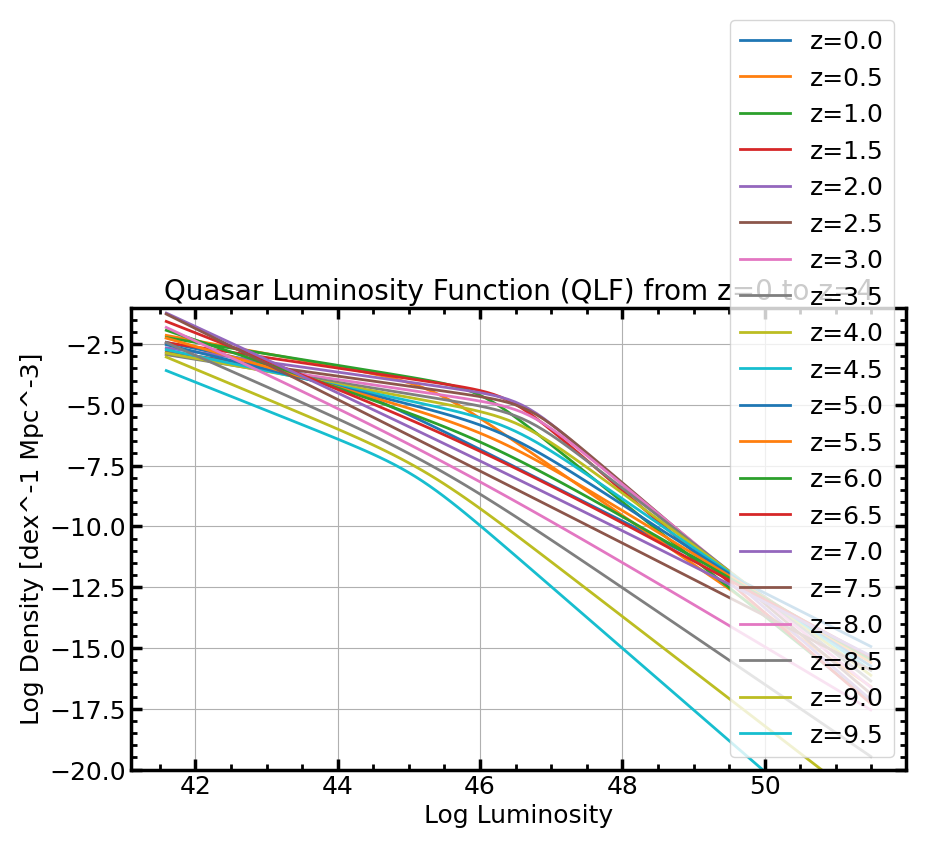

In [4]:
from utilities import return_bolometric_qlf

# Assuming the function to get the quasar LF is named `get_quasar_lf` in the utilities.py file

# Generate redshift values from 0 to 4
redshifts = np.linspace(0, 10, 200)

# Compute QLF for each redshift
qlf_values = [return_bolometric_qlf(redshift=z) for z in redshifts]

# Extract luminosity and density values
luminosities = qlf_values[0][0]  # Assuming luminosities are the same for all redshifts
Mi = 90 - 2.5*luminosities #TODO: K-correction

# Extract densities for each redshift
densities = np.array([qlf[1] for qlf in qlf_values])


# Plot the QLF
plt.figure(figsize=(10, 6))
for i, z in enumerate(redshifts[::10]):  # Plot every 10th redshift for clarity
    plt.plot(luminosities, densities[i * 10], label=f'z={z:.1f}')
    #plt.plot(apparent_magnitudes, densities[i * 10], label=f'z={z:.1f} (apparent)')
plt.xlabel('Log Luminosity')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Quasar Luminosity Function (QLF) from z=0 to z=4')
plt.ylim(-20, -1)
plt.legend()
plt.grid()
plt.show()


#### Apparent magnitude distribution

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


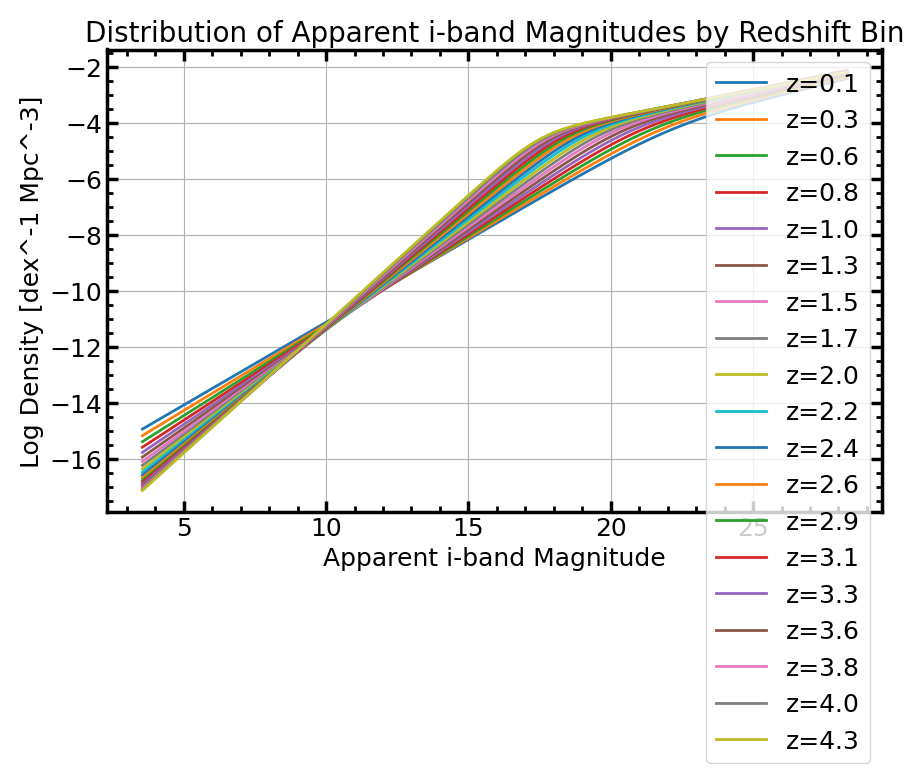

In [43]:
from scipy.interpolate import interp1d

alpha_nu = -0.5

z_bins = np.linspace(0.1, 4.5, 20)
area_deg2 = 20  # example survey area in deg^2
area_sr = area_deg2 * (np.pi/180)**2  # convert to steradians

# Compute apparent i-band magnitudes for each redshift bin
apparent_magnitude_distributions = []
sampled_apparent_magnitudes = []

expected_counts = []
for i in range(len(z_bins)-1):

    z1, z2 = z_bins[i], z_bins[i+1]
    z_mid = 0.5 * (z1 + z2)

    # Compute the cumulative distribution function (CDF)
    cdf = np.cumsum(10**densities[i,:])
    cdf /= cdf[-1]  # Normalize to make it a proper CDF

    # Create an interpolation function for the inverse CDF
    inverse_cdf = interp1d(cdf, luminosities, bounds_error=False, fill_value="extrapolate")

    phi_integral = np.trapz(10**densities[i], luminosities)

    # Comoving volume in this redshift bin and area
    v1 = cosmo.comoving_volume(z1).value # in Mpc^3
    v2 = cosmo.comoving_volume(z2).value
    dV = (v2 - v1) * (area_sr / (4 * np.pi))
    N = int(phi_integral * dV)

    # Generate random samples from a uniform distribution
    random_samples = np.random.uniform(0, 1, size=N)

    # Map the random samples through the inverse CDF to get samples
    sampled_luminosities = inverse_cdf(random_samples)

    # Convert sampled luminosities to absolute magnitudes Mi
    sampled_Mi = 90 - 2.5 * sampled_luminosities

    # Compute apparent magnitudes for the luminosity function at this redshift
    apparent_magnitudes_bin = Mi + 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)
    sampled_m = sampled_Mi + 5 * np.log10(cosmo.luminosity_distance(z).to(u.pc).value / 10)
    # Apply a simple K-correction (example: K(z) = -2.5 * log10(1+z))
    K_corr = -2.5 * (1 + alpha_nu) * np.log10(1 + z)
    sampled_m_obs = sampled_m + K_corr

    mask = sampled_m_obs < 25
    sampled_m_obs = sampled_m_obs[mask]

    apparent_magnitude_distributions.append((apparent_magnitudes_bin, densities[i]))
    sampled_apparent_magnitudes.append(sampled_m_obs)

# Plot the distribution of apparent i-band magnitudes for each redshift bin
plt.figure(figsize=(10, 6))
for i in range(0, len(z_bins)-1):
    print(i)
    apparent_magnitudes_bin, density_bin = apparent_magnitude_distributions[i]
    plt.plot(apparent_magnitudes_bin, density_bin, label=f'z={z_bins[i]:.1f}')

plt.xlabel('Apparent i-band Magnitude')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Distribution of Apparent i-band Magnitudes by Redshift Bin')
plt.legend()
plt.grid()
plt.show()

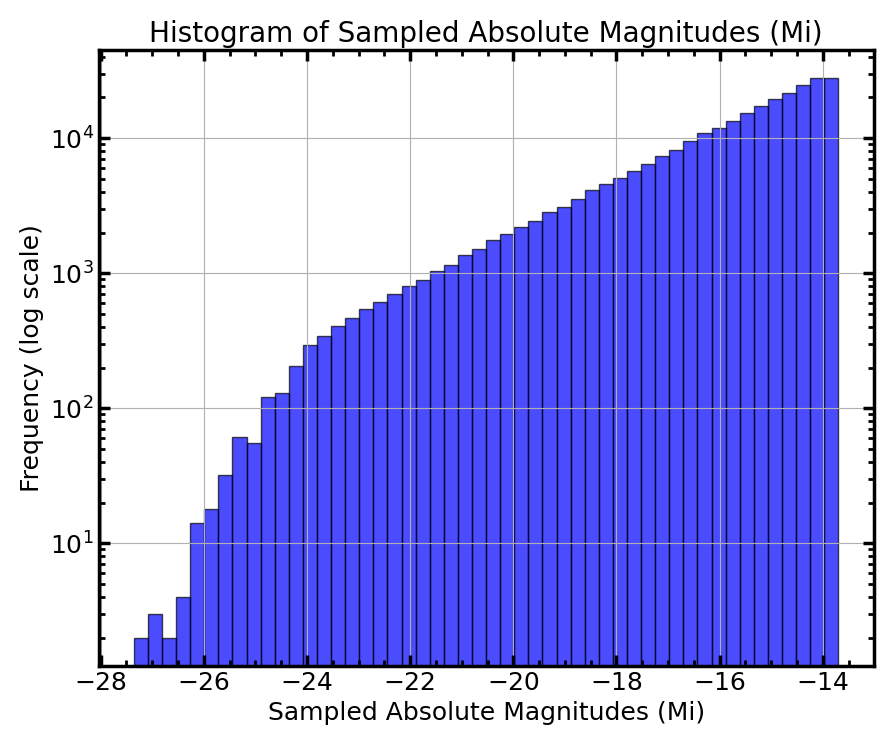

In [44]:
plt.hist(sampled_Mi, bins=50, log=True, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Sampled Absolute Magnitudes (Mi)')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Sampled Absolute Magnitudes (Mi)')
plt.grid(True)
plt.show()

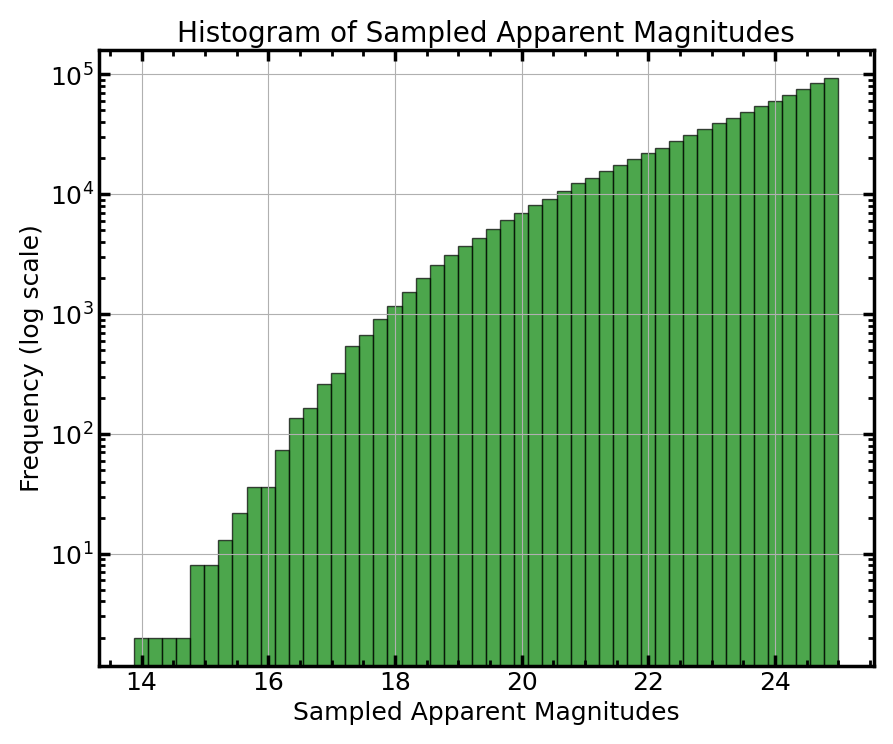

In [45]:
# Flatten the list of sampled_apparent_magnitudes into a single array
flattened_sampled_apparent_magnitudes = np.concatenate(sampled_apparent_magnitudes)
flattened_sampled_apparent_magnitudes = flattened_sampled_apparent_magnitudes[np.isfinite(flattened_sampled_apparent_magnitudes)]

# Plot the histogram
plt.hist(flattened_sampled_apparent_magnitudes, bins=50, log=True, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Sampled Apparent Magnitudes')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Sampled Apparent Magnitudes')
plt.grid(True)
plt.show()

In [46]:
for idx, (z_val, mags) in enumerate(zip(z_bins[:-1], sampled_apparent_magnitudes)):
    print(f"Redshift {z_val:.2f}: {len(mags)} quasars")

Redshift 0.10: 1310 quasars
Redshift 0.33: 4974 quasars
Redshift 0.56: 10987 quasars
Redshift 0.79: 18641 quasars
Redshift 1.03: 26128 quasars
Redshift 1.26: 33696 quasars
Redshift 1.49: 40659 quasars
Redshift 1.72: 46926 quasars
Redshift 1.95: 52393 quasars
Redshift 2.18: 56003 quasars
Redshift 2.42: 59489 quasars
Redshift 2.65: 61373 quasars
Redshift 2.88: 63554 quasars
Redshift 3.11: 64525 quasars
Redshift 3.34: 64051 quasars
Redshift 3.57: 63834 quasars
Redshift 3.81: 62546 quasars
Redshift 4.04: 61436 quasars
Redshift 4.27: 59803 quasars


Redshift 0.10: 1310 quasars
[24.19526032 22.67297473 24.96078232 ... 23.70529639 22.12111399
 24.90818596]
Redshift 0.33: 4974 quasars
[23.67831699 23.41306008 23.48956955 ... 24.48844509 24.07559845
 23.68831816]
Redshift 0.56: 10987 quasars
[23.18976641 24.67717176 24.09597983 ... 23.1310409  23.74237013
 22.53957551]
Redshift 0.79: 18641 quasars
[24.47203525 23.57743129 20.05680488 ... 24.9774075  21.02798453
 24.24709293]
Redshift 1.03: 26128 quasars
[21.34916127 20.23003207 23.20760396 ... 22.07738211 22.68066737
 23.49452143]
Redshift 1.26: 33696 quasars
[24.89076702 23.80220853 23.44399558 ... 24.29352715 24.60134025
 23.83294356]
Redshift 1.49: 40659 quasars
[24.09714482 24.76173269 23.76318549 ... 23.4169244  23.85544527
 23.82959669]
Redshift 1.72: 46926 quasars
[24.87256589 23.68178382 24.75350835 ... 24.56900069 20.41299943
 23.7194832 ]
Redshift 1.95: 52393 quasars
[21.48862831 24.67474594 24.21805616 ... 23.45225284 22.88376687
 24.49631357]
Redshift 2.18: 56003 quasars
[

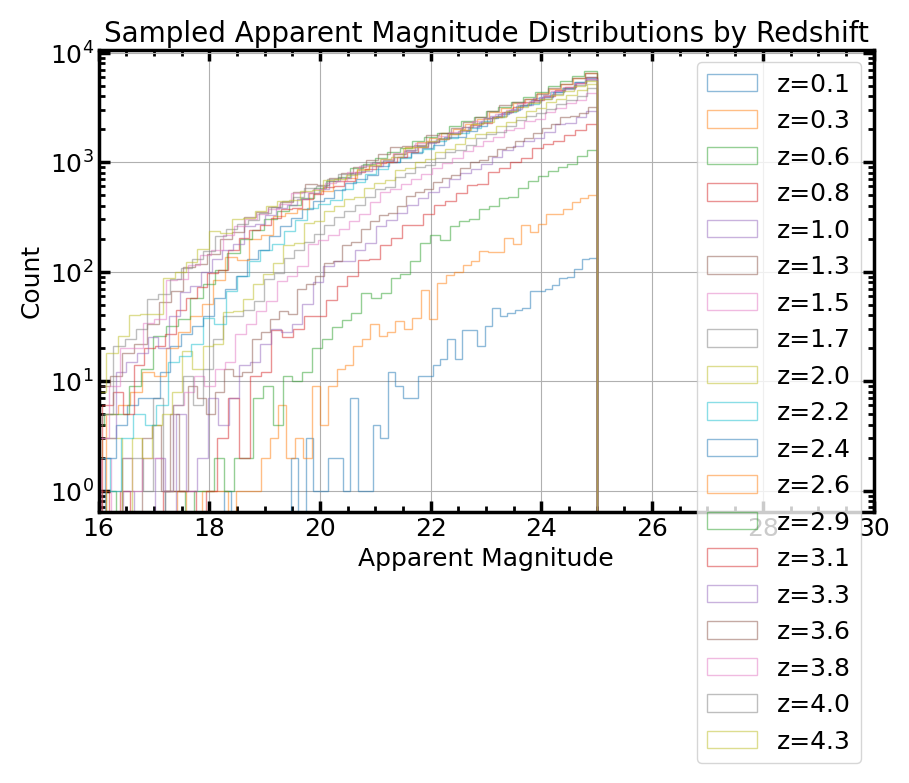

In [47]:
plt.figure(figsize=(10, 6))
for idx, (z_val, mags) in enumerate(zip(z_bins[:-1], sampled_apparent_magnitudes)):
        print(f"Redshift {z_val:.2f}: {len(mags)} quasars")
        plt.hist(mags[np.isfinite(mags)], bins=50, alpha=0.5, label=f'z={z_val:.1f}', histtype='step')
        print(mags[np.isfinite(mags)])
plt.xlabel('Apparent Magnitude')
plt.ylabel('Count')
plt.semilogy()
plt.xlim(16, 30)
plt.title('Sampled Apparent Magnitude Distributions by Redshift')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import h5py

with h5py.File('/Users/colinburke/research/isaque/eztaox/tutorials/sampled_apparent_magnitudes_redshift_vol.h5', 'w') as h5file:
    redshift_group = h5file.create_group('redshift_bin')
    for i, (z, mags) in enumerate(zip(z_bins[:-1], sampled_apparent_magnitudes)):
        ds = redshift_group.create_dataset(f'bin_{i}', data=mags)
        ds.attrs['redshift'] = z